In [96]:
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
# Import libraries for

In [97]:
data_dir = '../data/yfinance_data/'
stock_files = os.listdir(data_dir)
stock_data = {}
for file in stock_files:
    if file.endswith('.csv'):
        stock_symbol = file.split('_')[0]
        df = pd.read_csv(os.path.join(data_dir, file))
        stock_data[stock_symbol] = df
# Load stock data files for analysis

In [98]:
for symbol, df in stock_data.items():
    print(f"{symbol} - Missing Values: {df.isnull().sum()}")
    print(f"{symbol} - Data Types: {df.dtypes}\n")
# Check missing values and data types for each stock

AAPL - Missing Values: Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
AAPL - Data Types: Date             object
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

AMZN - Missing Values: Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
AMZN - Data Types: Date             object
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

GOOG - Missing Values: Date            0
Open            0
High            0
Low             0
Close    

In [106]:
def calculate_indicators(df):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df['MA50'] = talib.SMA(df['Close'], timeperiod=50)
    df['MA200'] = talib.SMA(df['Close'], timeperiod=200)
    df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
    df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
    return df

for symbol, df in stock_data.items():
    stock_data[symbol] = calculate_indicators(df)
print(stock_data['AAPL'].head())
# Calculate technical indicators for stock data and display sample

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600   
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800   
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000   
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600   
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600   

   Dividends  Stock Splits  MA50  MA200  RSI  MACD  MACD_Signal  MACD_Hist  \
0        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
1        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
2        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
3        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
4        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   

   Daily_Return  Sharpe_Ratio  
0           NaN     -0.320042 

In [107]:
def calculate_pynance_metrics(df):
    df['Daily_Return'] = df['Close'].pct_change()
    returns_series = df['Daily_Return'].dropna()
    if len(returns_series) > 0:
        excess_return = returns_series.mean() - 0.01
        volatility = returns_series.std()
        df['Sharpe_Ratio'] = excess_return / volatility if volatility != 0 else np.nan
    else:
        df['Sharpe_Ratio'] = np.nan
    return df

for symbol, df in stock_data.items():
    stock_data[symbol] = calculate_pynance_metrics(df)
print(stock_data['AAPL'].head())
# Compute financial metrics including Sharpe Ratio

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 1980-12-12  0.128348  0.128906  0.128348  0.128348   0.098943  469033600   
1 1980-12-15  0.122210  0.122210  0.121652  0.121652   0.093781  175884800   
2 1980-12-16  0.113281  0.113281  0.112723  0.112723   0.086898  105728000   
3 1980-12-17  0.115513  0.116071  0.115513  0.115513   0.089049   86441600   
4 1980-12-18  0.118862  0.119420  0.118862  0.118862   0.091630   73449600   

   Dividends  Stock Splits  MA50  MA200  RSI  MACD  MACD_Signal  MACD_Hist  \
0        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
1        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
2        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
3        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   
4        0.0           0.0   NaN    NaN  NaN   NaN          NaN        NaN   

   Daily_Return  Sharpe_Ratio  
0           NaN     -0.320042 

C:\Users\Misirak\AppData\Local\Temp\ipykernel_26380\622964555.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Misirak\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


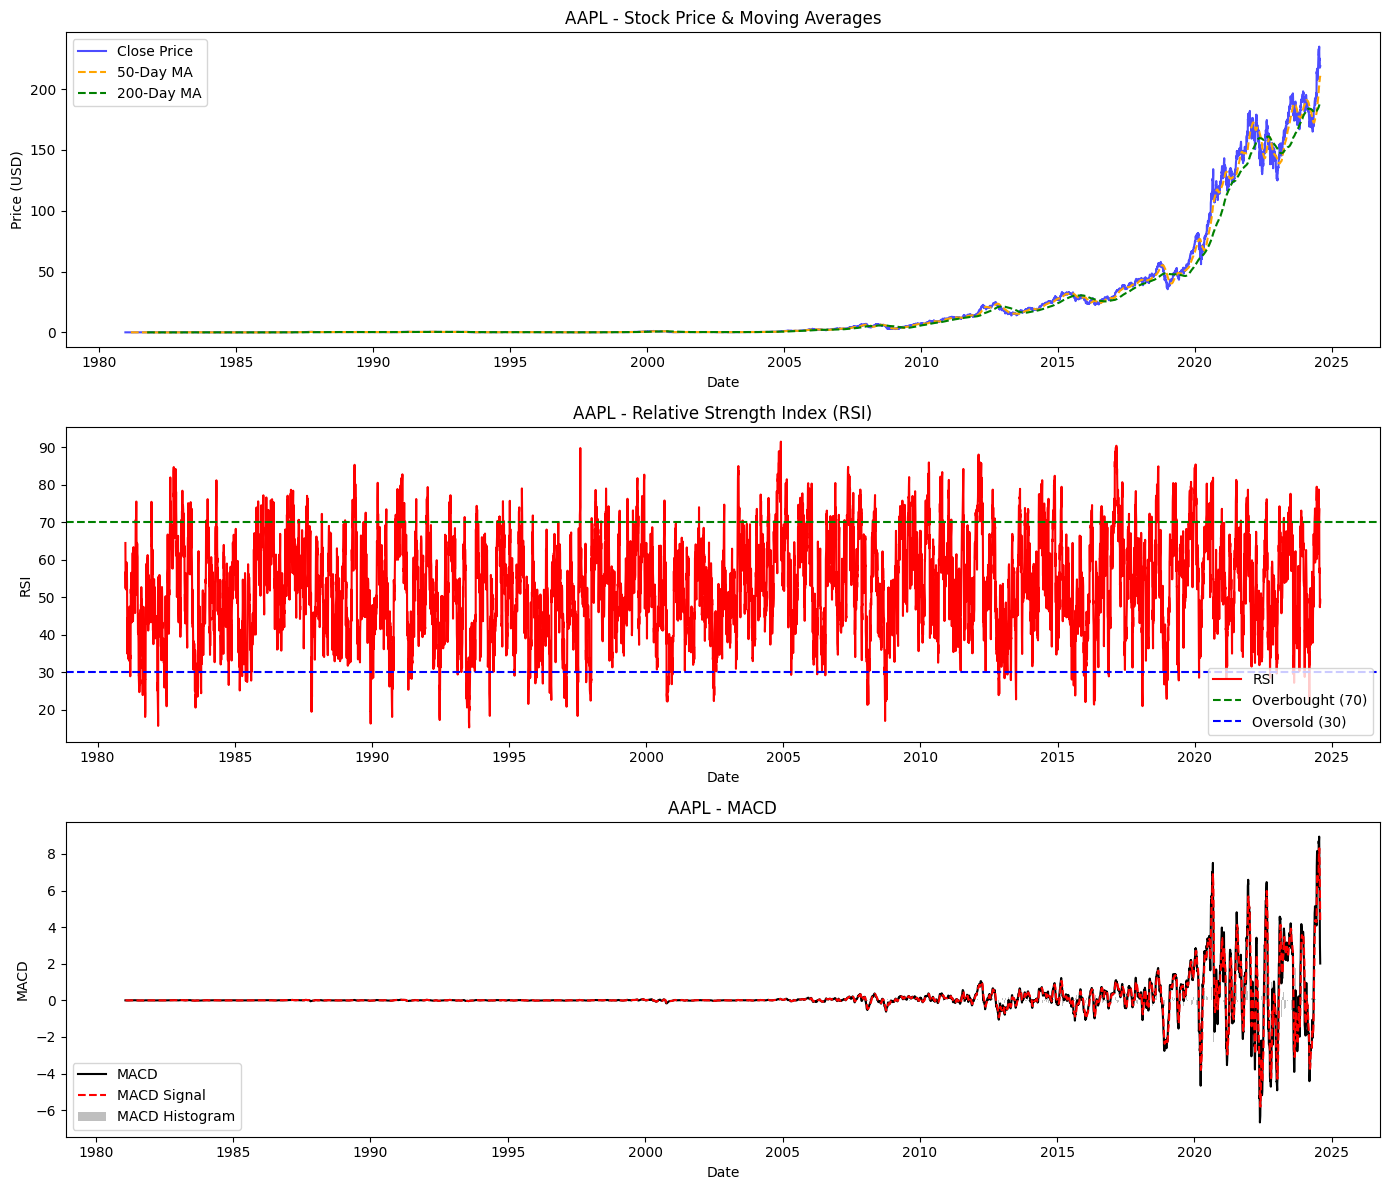

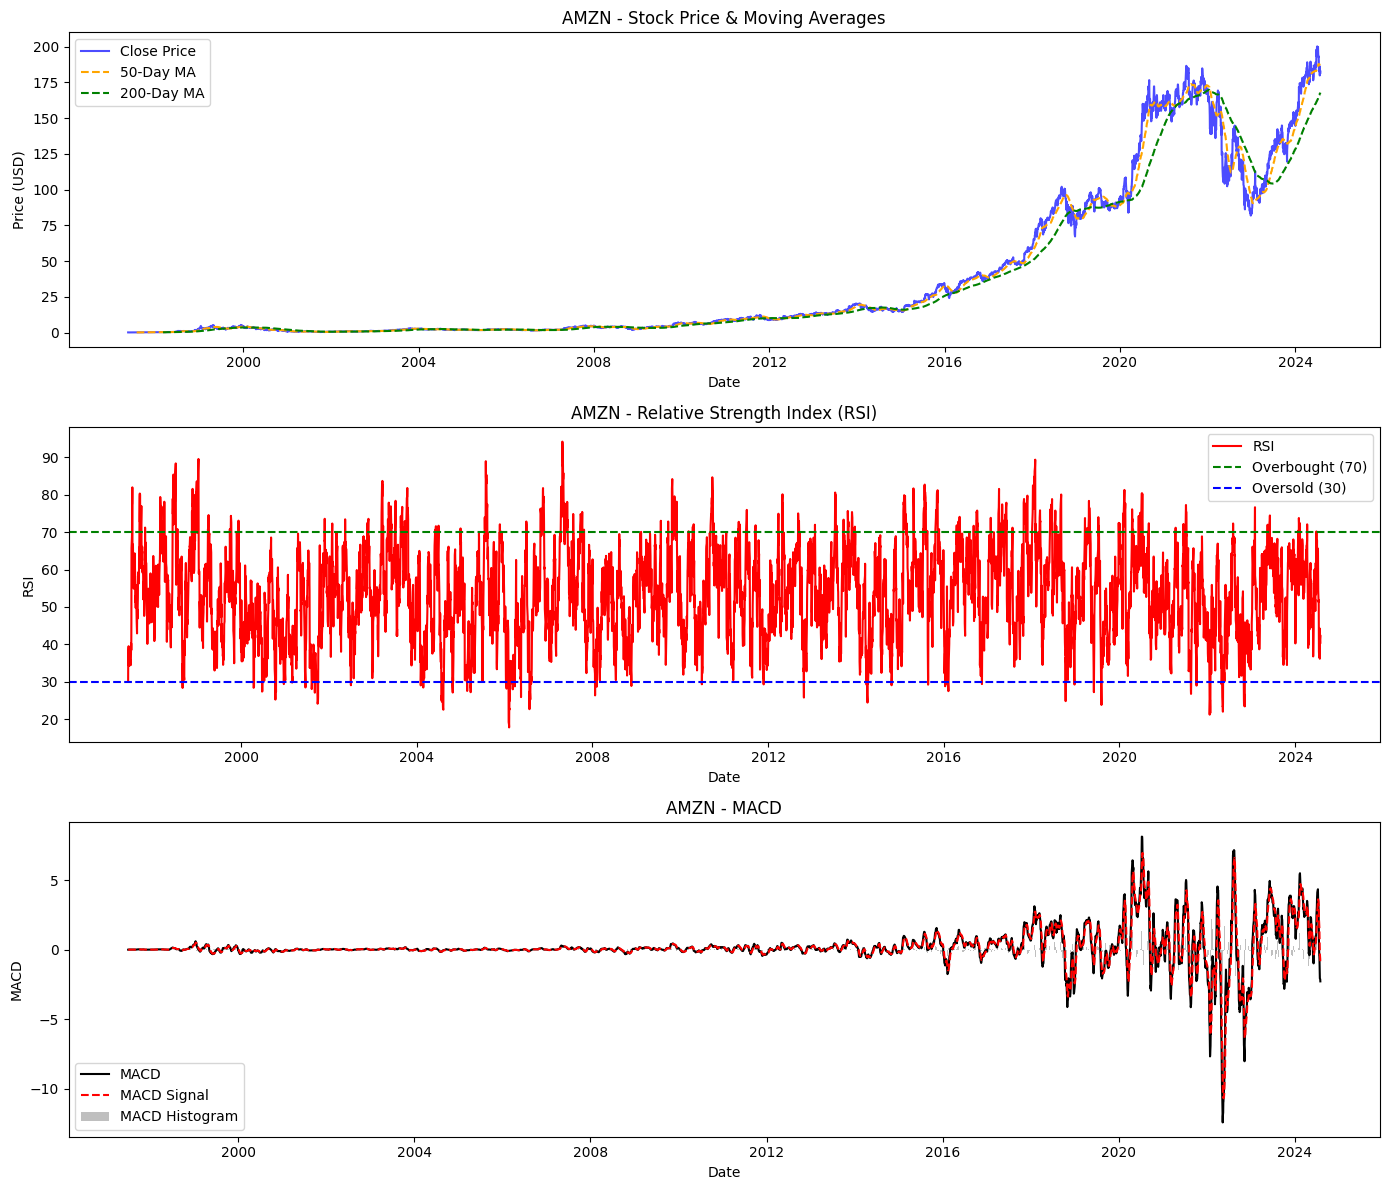

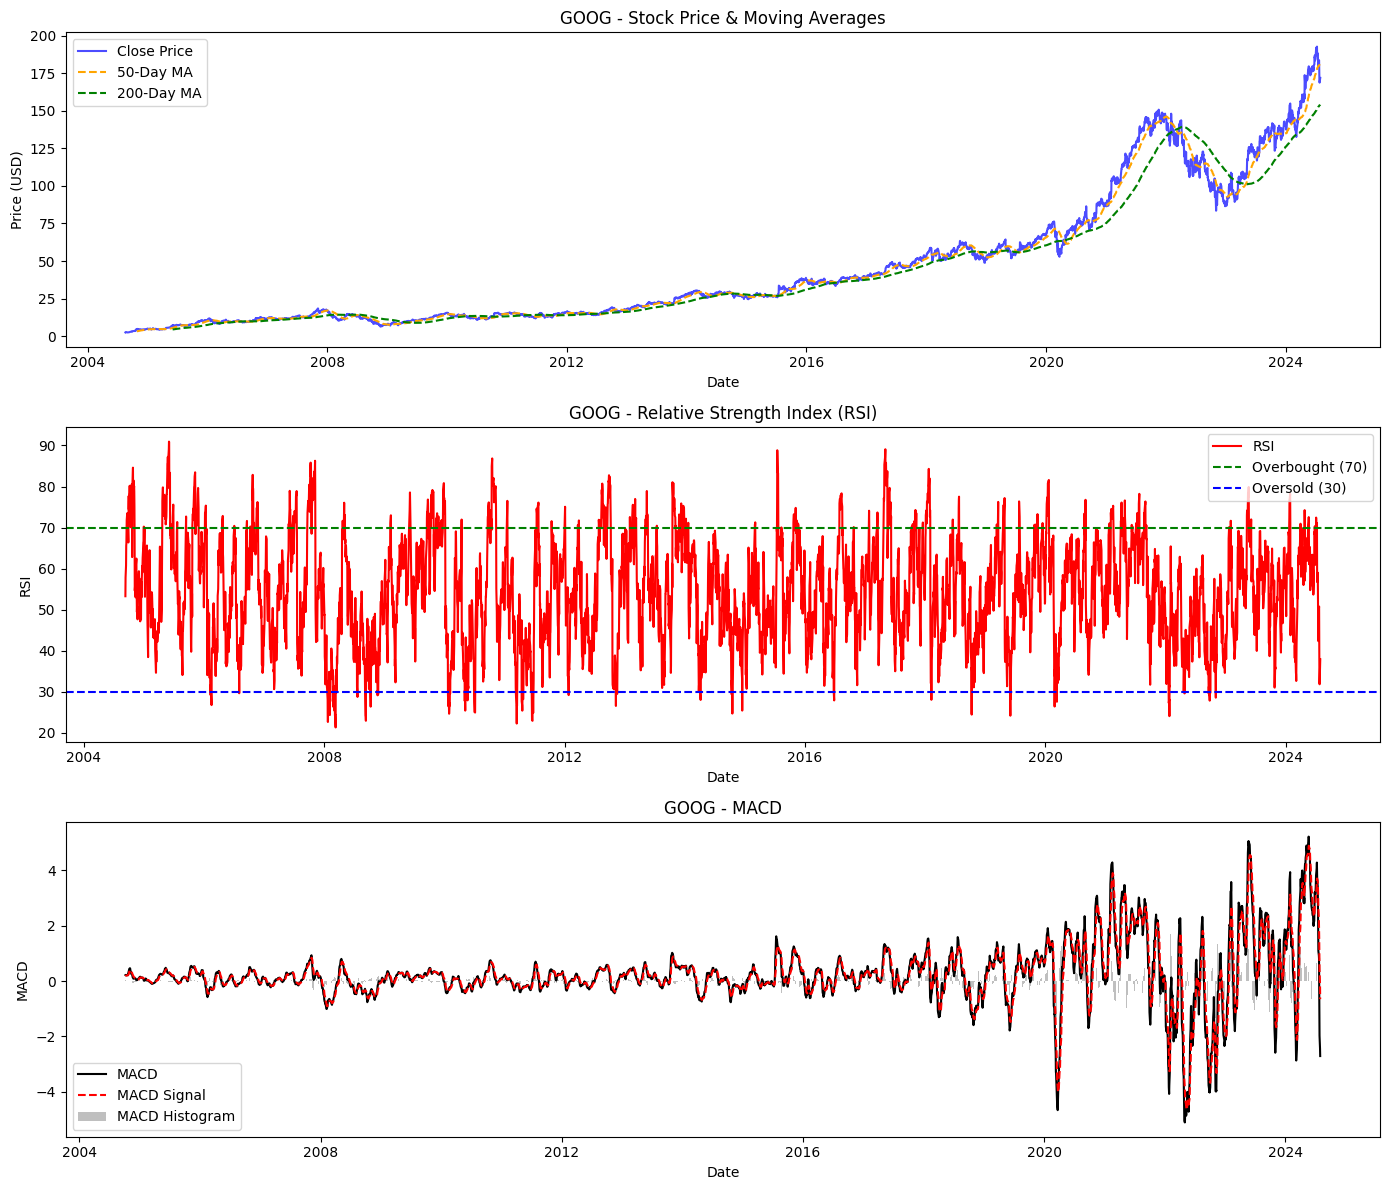

In [108]:
def plot_technical_indicators(df, symbol):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    axes[0].plot(df['Date'], df['Close'], label='Close Price', color='blue', alpha=0.7)
    axes[0].plot(df['Date'], df['MA50'], label='50-Day MA', color='orange', linestyle='--')
    axes[0].plot(df['Date'], df['MA200'], label='200-Day MA', color='green', linestyle='--')
    axes[0].set_title(f'{symbol} - Stock Price & Moving Averages')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()

    axes[1].plot(df['Date'], df['RSI'], label='RSI', color='red')
    axes[1].axhline(70, color='green', linestyle='--', label='Overbought (70)')
    axes[1].axhline(30, color='blue', linestyle='--', label='Oversold (30)')
    axes[1].set_title(f'{symbol} - Relative Strength Index (RSI)')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('RSI')
    axes[1].legend()

    axes[2].plot(df['Date'], df['MACD'], label='MACD', color='black')
    axes[2].plot(df['Date'], df['MACD_Signal'], label='MACD Signal', color='red', linestyle='--')
    axes[2].bar(df['Date'], df['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.5)
    axes[2].set_title(f'{symbol} - MACD')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('MACD')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

selected_symbols = ['AAPL', 'AMZN', 'GOOG']
for symbol in selected_symbols:
    if symbol in stock_data:
        plot_technical_indicators(stock_data[symbol], symbol)
# Visualize technical indicators for selected stocks

In [109]:
news_df = pd.read_csv('../data/news_with_sentiment.csv')
print(news_df.head())
print(news_df.isnull().sum())
print(news_df.dtypes)
# Load and explore the saved news sentiment data

         Date stock  sentiment
0  2011-04-28   DEJ   0.000000
1  2011-04-28   DGP   0.000000
2  2011-04-28   ESR   0.136364
3  2011-04-29   AIA  -0.166667
4  2011-04-29   GDL   0.500000
Date         0
stock        0
sentiment    0
dtype: int64
Date          object
stock         object
sentiment    float64
dtype: object


In [110]:
news_df['date'] = pd.to_datetime(news_df['Date'], errors='coerce')

stock_mapping = {
    'ESR': 'AAPL',
    'AIA': 'AMZN',
    'GDL': 'GOOG',
    'PTM': 'META',
    'SCJ': 'MSFT'
}
news_df['stock'] = news_df['stock'].map(stock_mapping).fillna(news_df['stock'])

aggregated_news = news_df.groupby(['date', 'stock'])['sentiment'].mean().reset_index()
if aggregated_news['date'].dt.tz is not None:
    aggregated_news['Date'] = aggregated_news['date'].dt.tz_convert('UTC')
else:
    aggregated_news['Date'] = aggregated_news['date'].dt.tz_localize('UTC')
aggregated_news = aggregated_news.drop(columns=['date'])
aggregated_news = aggregated_news.groupby(['Date', 'stock'])['sentiment'].mean().reset_index()
print(aggregated_news.head())
# Clean dates and aggregate sentiment by day per stock

                       Date stock  sentiment
0 2011-04-28 00:00:00+00:00  AAPL   0.136364
1 2011-04-28 00:00:00+00:00   DEJ   0.000000
2 2011-04-28 00:00:00+00:00   DGP   0.000000
3 2011-04-29 00:00:00+00:00  AMZN  -0.166667
4 2011-04-29 00:00:00+00:00  GOOG   0.500000


In [123]:
merged_data = pd.DataFrame()
valid_stocks = list(stock_data.keys())  # Get stocks from stock_data
for symbol in valid_stocks:
    data = stock_data[symbol]
    # Handle timezone-aware or naive dates
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
    if data['Date'].dt.tz is not None:
        data['Date'] = data['Date'].dt.tz_convert('UTC')  # Convert if already aware
    else:
        data['Date'] = data['Date'].dt.tz_localize('UTC')  # Localize if naive
    data['stock'] = symbol
    merge_df = pd.DataFrame({
        'Date': data['Date'].dt.date,  # Extract date as Python date
        'stock': data['stock'],
        'Daily_Return': data['Daily_Return']
    })
    aggregated_news_filtered = aggregated_news[aggregated_news['stock'].isin(valid_stocks)].copy()  # Create a copy
    aggregated_news_filtered['Date'] = pd.to_datetime(aggregated_news_filtered['Date'], errors='coerce').dt.date  # Match with Python date
    merged = pd.merge(merge_df, aggregated_news_filtered, on=['Date', 'stock'], how='inner')
    merged_data = pd.concat([merged_data, merged], axis=0)

merged_data = merged_data.dropna(subset=['Daily_Return', 'sentiment'])
print(merged_data.head())
# Merge stock and news data with daily alignment, handling timezone flexibly

         Date stock  Daily_Return  sentiment
0  2011-04-28  AAPL     -0.009710   0.136364
1  2011-05-19  AAPL      0.001942   0.000000
2  2011-11-25  AAPL     -0.009319   0.136364
3  2012-02-23  AAPL      0.006530   0.000000
4  2012-02-24  AAPL      0.011658   0.000000


In [124]:
correlations = {}
for symbol in merged_data['stock'].unique():
    stock_subset = merged_data[merged_data['stock'] == symbol]
    if len(stock_subset) > 1:
        corr, p_value = pearsonr(stock_subset['Daily_Return'], stock_subset['sentiment'])
        correlations[symbol] = {'correlation': corr, 'p_value': p_value}
    else:
        correlations[symbol] = {'correlation': np.nan, 'p_value': np.nan}

print(pd.DataFrame(correlations).T)
# Compute correlation between daily returns and sentiment

      correlation   p_value
AAPL    -0.005221  0.965279
AMZN     0.176896  0.224016
GOOG     0.121848  0.472499
META     0.010331  0.927066
MSFT    -0.078244  0.729262
NVDA     0.361803  0.247832
TSLA     0.016618  0.918936


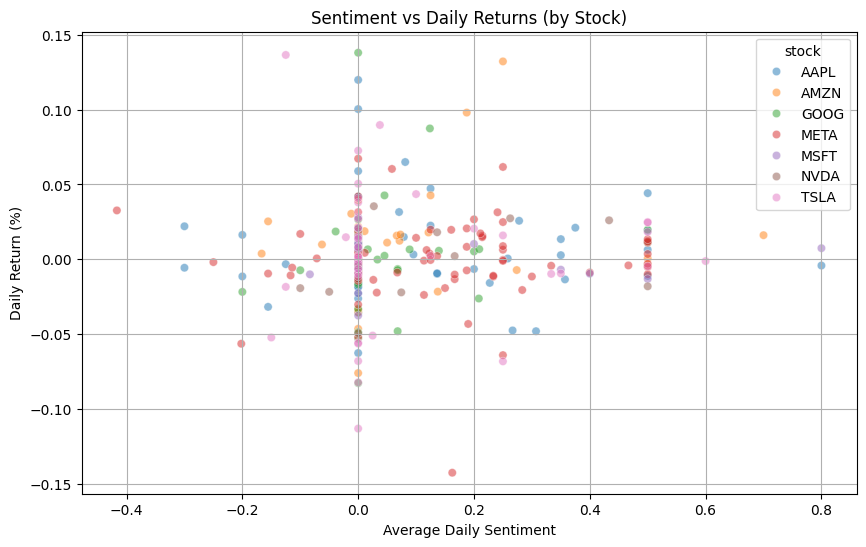

In [125]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='sentiment', y='Daily_Return', hue='stock', alpha=0.5)
plt.title('Sentiment vs Daily Returns (by Stock)')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()
# Visualize relationship between sentiment and daily returns

In [126]:
print("Investment Strategy Suggestions:")
for symbol, stats in correlations.items():
    corr = stats['correlation']
    p = stats['p_value']
    if not np.isnan(corr):
        print(f"For {symbol}: Correlation = {corr:.4f} (p-value = {p:.4f})")
        if p < 0.05 and corr > 0:
            print("  - Strategy: Buy when average daily sentiment > 0.2 and RSI < 30 (oversold with positive news).")
        elif corr < 0:
            print("  - Strategy: Consider shorting on high positive sentiment if correlation is negative.")
        else:
            print("  - No strong correlation; use other indicators like MACD crossovers for decisions.")
    else:
        print(f"For {symbol}: Insufficient data for correlation.")
# Provide investment strategy based on correlation analysis

Investment Strategy Suggestions:
For AAPL: Correlation = -0.0052 (p-value = 0.9653)
  - Strategy: Consider shorting on high positive sentiment if correlation is negative.
For AMZN: Correlation = 0.1769 (p-value = 0.2240)
  - No strong correlation; use other indicators like MACD crossovers for decisions.
For GOOG: Correlation = 0.1218 (p-value = 0.4725)
  - No strong correlation; use other indicators like MACD crossovers for decisions.
For META: Correlation = 0.0103 (p-value = 0.9271)
  - No strong correlation; use other indicators like MACD crossovers for decisions.
For MSFT: Correlation = -0.0782 (p-value = 0.7293)
  - Strategy: Consider shorting on high positive sentiment if correlation is negative.
For NVDA: Correlation = 0.3618 (p-value = 0.2478)
  - No strong correlation; use other indicators like MACD crossovers for decisions.
For TSLA: Correlation = 0.0166 (p-value = 0.9189)
  - No strong correlation; use other indicators like MACD crossovers for decisions.
